<a href="https://colab.research.google.com/github/thaisja/projeto-aplicado4/blob/main/ENERGIA_EDA_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving CARGA_ENERGIA_2025.csv to CARGA_ENERGIA_2025 (1).csv


In [10]:
import pandas as pd

df = pd.read_csv('CARGA_ENERGIA_2025.csv', sep=';')

In [11]:
df.columns

Index(['id_subsistema', 'nom_subsistema', 'din_instante',
       'val_cargaenergiamwmed'],
      dtype='object')

In [12]:
df['din_instante'] = pd.to_datetime(df['din_instante'])
df = df.sort_values('din_instante')
df.set_index('din_instante', inplace=True)

# selecionar variável principal
serie = df['val_cargaenergiamwmed']

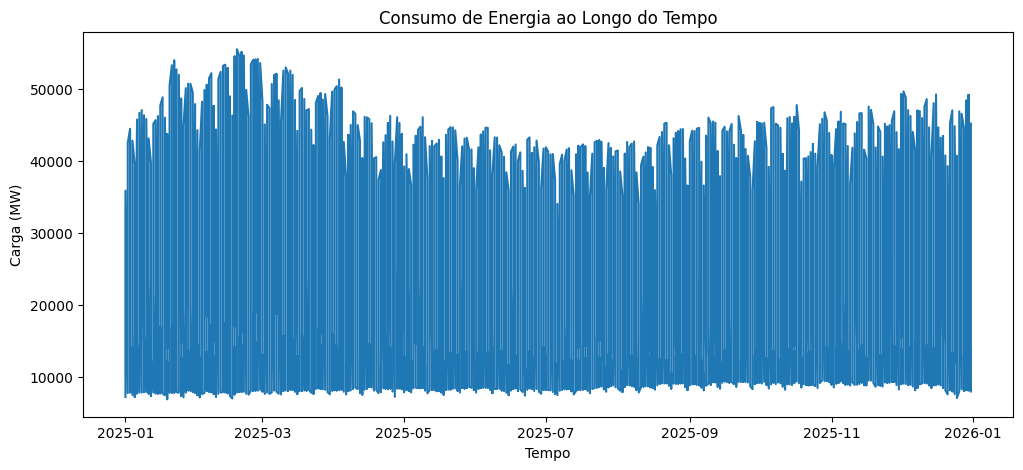

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(serie)
plt.title('Consumo de Energia ao Longo do Tempo')
plt.xlabel('Tempo')
plt.ylabel('Carga (MW)')
plt.show()

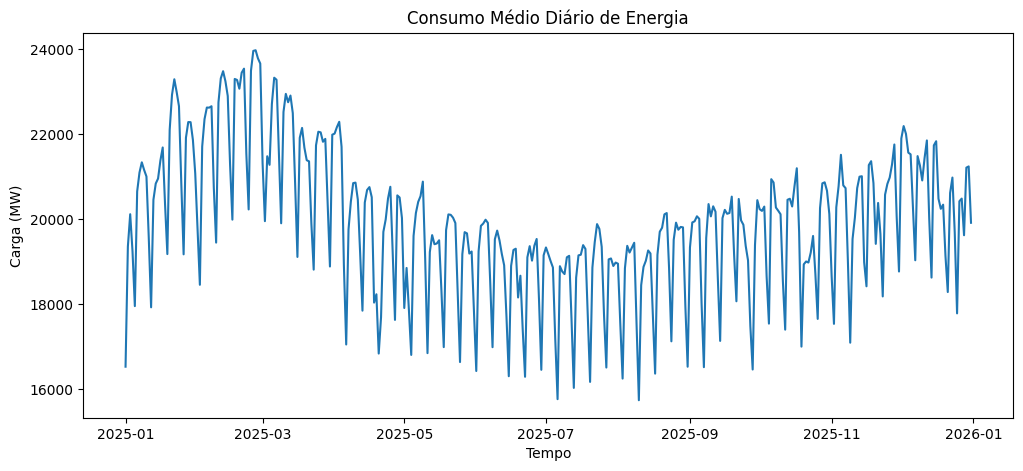

In [14]:
serie_diaria = serie.resample('D').mean()

plt.figure(figsize=(12,5))
plt.plot(serie_diaria)
plt.title('Consumo Médio Diário de Energia')
plt.xlabel('Tempo')
plt.ylabel('Carga (MW)')
plt.show()

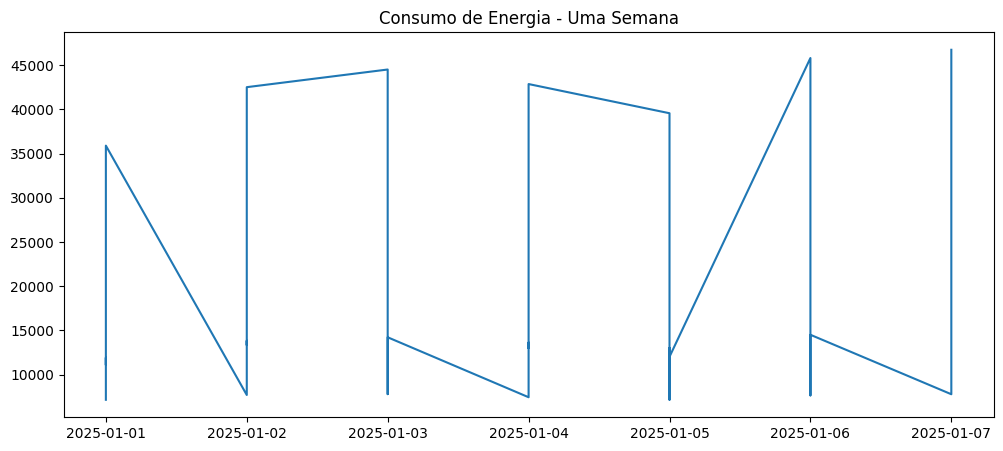

In [15]:
serie_semana = serie['2025-01-01':'2025-01-07']

plt.figure(figsize=(12,5))
plt.plot(serie_semana)
plt.title('Consumo de Energia - Uma Semana')
plt.show()

A análise exploratória da série temporal de consumo energético revelou padrões relevantes ao longo do período analisado. Ao considerar a média diária, observa-se uma variação ao longo do ano, com níveis mais elevados no início e no final do período e redução no meio do ano, indicando a presença de tendência associada a fatores sazonais de longo prazo.

Adicionalmente, ao analisar um recorte semanal da série, identifica-se um padrão recorrente de variação ao longo dos dias, evidenciando forte sazonalidade diária. Esse comportamento é característico do consumo energético, que varia de acordo com a atividade econômica e os ciclos de uso ao longo do dia.


A presença de padrões cíclicos em diferentes escalas temporais indica que a série possui múltiplos níveis de sazonalidade, incluindo componentes diárias e possivelmente semanais, além de variações ao longo do ano. Dessa forma, a série apresenta comportamento não estacionário, exigindo técnicas apropriadas de modelagem para capturar tais características.

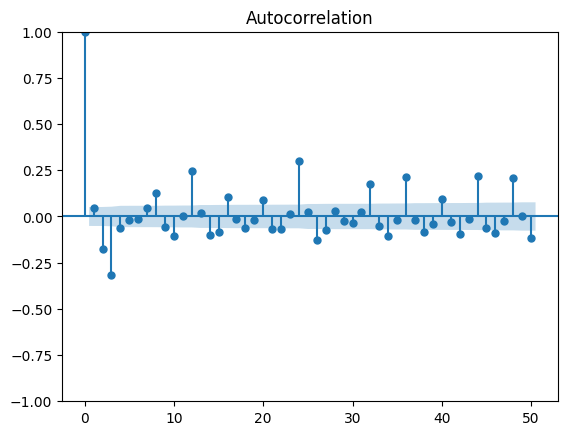

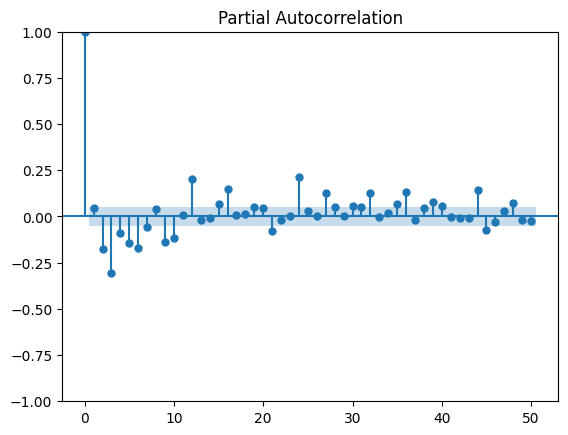

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(serie, lags=50)
plt.show()

plot_pacf(serie, lags=50)
plt.show()

ANÁLISE DE AUTOCORRELAÇÃO

A análise da função de autocorrelação (ACF) evidencia a existência de dependência temporal na série, com valores significativos nos primeiros lags. Esse comportamento indica que os valores atuais do consumo energético estão relacionados a observações anteriores, característica típica de séries temporais reais.

Observa-se ainda que, à medida que o número de defasagens aumenta, os coeficientes de autocorrelação tendem a se aproximar de zero, sugerindo redução da influência de valores mais distantes no tempo.

ANÁLISE PACF

A função de autocorrelação parcial (PACF) apresenta poucos lags com relevância estatística, indicando que a estrutura da série pode ser explicada por um número limitado de termos autoregressivos. Esse resultado sugere que modelos relativamente simples podem ser suficientes para capturar o comportamento da série.

Em conjunto, os resultados da ACF e PACF indicam que a série possui dependência temporal significativa, mas não apresenta comportamento puramente aleatório. Dessa forma, a série é adequada para modelagem utilizando técnicas estatísticas de séries temporais, como modelos ARIMA e suas variações.

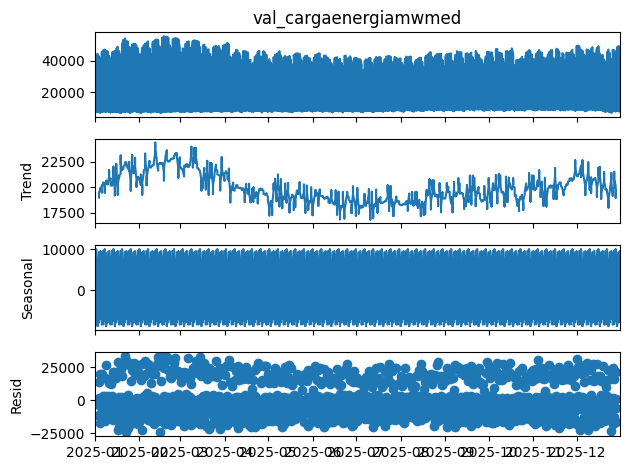

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposicao = seasonal_decompose(serie, model='additive', period=24)

decomposicao.plot()
plt.show()

A decomposição da série temporal permitiu identificar claramente três componentes principais: tendência, sazonalidade e resíduo

A componente de tendência evidencia variações ao longo do período analisado, com níveis mais elevados no início do ano, redução ao longo dos meses intermediários e posterior recuperação no final do período. Esse comportamento indica a influência de fatores sazonais de longo prazo no consumo energético.

A componente sazonal apresenta um padrão altamente regular e repetitivo, evidenciando forte sazonalidade associada ao ciclo diário de consumo. Esse resultado está alinhado com o comportamento esperado do consumo energético, que varia conforme os horários do dia.

Por fim, o componente residual não apresenta estrutura definida, caracterizando-se como ruído aleatório. Isso indica que as principais variações sistemáticas da série foram capturadas pelas componentes de tendência e sazonalidade.

Com base nas análises realizadas — incluindo visualização gráfica, autocorrelação e decomposição — conclui-se que a série temporal apresenta tendência não linear, forte sazonalidade diária e componente residual aleatória, caracterizando-se como uma série não estacionária e adequada para modelagem preditiva.

In [19]:
serie.describe()

,val_cargaenergiamwmed
count,1460.000000
mean,19902.226693
std,14416.610779
min,6858.350125
25%,9495.465667
50%,13516.199021
75%,22933.200479
max,55584.896708


In [20]:
serie_diaria.describe()

,val_cargaenergiamwmed
count,365.000000
mean,19902.226693
std,1691.591684
min,15734.435000
25%,18974.078927
50%,19897.947469
75%,20878.286271
max,23970.191115
